# FRED Retail Sales as a Leading Indicator for Walmart Quarterly Revenue
**YipitData AI Engineer Take-Home Exercise**

**Question:** Does the FRED monthly retail-sales index (RSXFS) predict Walmart's quarterly revenue better than a naive baseline? If yes, by how much, and what should we worry about?

---

### Approach Overview
1. Load and align data
2. Define two naive baselines (seasonal-naive, random walk with drift)
3. Test FRED signal as predictor — with proper out-of-sample time-series splits
4. Assess 'leading' properties: does a 1-quarter lag help?
5. Stability analysis: does the relationship hold outside recession/COVID periods?
6. Report MAPE, report wins, report caveats honestly

In [1]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import statsmodels.api as sm
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_percentage_error

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({'figure.dpi': 120, 'font.size': 11})

print('Libraries loaded.')

Libraries loaded.


## 1. Load & Align Data

**Timing note (look-ahead bias):** Walmart reports quarterly results ~3-4 weeks after quarter end. So Q3 revenue (quarter ending Oct 31) is released mid-November — *not* available on Oct 31. We model the signal as available at quarter-end for the retail index, but treat Walmart revenue as known only after the filing lag. For this exercise we assume one quarter's lag is conservative enough, which is standard practice.

In [2]:
# Load raw data
retail  = pd.read_csv('data/retail_sales_fred.csv', parse_dates=['date'])
revenue = pd.read_csv('data/walmart_revenue.csv',   parse_dates=['date'])

print(f"Retail sales:    {len(retail)} monthly obs  | {retail.date.min().date()} – {retail.date.max().date()}")
print(f"Walmart revenue: {len(revenue)} quarterly obs | {revenue.date.min().date()} – {revenue.date.max().date()}")
print(f"Walmart revenue range: ${revenue.value.min()/1e9:.1f}B – ${revenue.value.max()/1e9:.1f}B")

# ── Resample retail monthly → quarterly (SUM of 3 months) ────────────────────
retail_q = (
    retail.set_index('date')
    .resample('QE')['value']
    .sum()
    .reset_index()
    .rename(columns={'value': 'retail_sum'})
)

# ── Align to Walmart's fiscal calendar ───────────────────────────────────────
# Walmart's fiscal quarters end Jan/Apr/Jul/Oct — not standard Mar/Jun/Sep/Dec.
# Fix: shift Walmart dates back 1 month so both series share the same Period label.
revenue['date_shifted'] = revenue['date'] - pd.DateOffset(months=1)
retail_q['quarter'] = retail_q['date'].dt.to_period('Q')
revenue['quarter']  = revenue['date_shifted'].dt.to_period('Q')

print("\nRetail (resampled, first 5 quarters):")
print(retail_q[['quarter', 'retail_sum']].head(5).to_string(index=False))
print("\nWalmart revenue (first 5 quarters):")
print(revenue[['quarter', 'value']].head(5).to_string(index=False))


Retail sales:    195 monthly obs  | 2010-01-01 – 2026-03-01
Walmart revenue: 65 quarterly obs | 2010-01-31 – 2026-01-31
Walmart revenue range: $99.8B – $185.5B

Retail (resampled, first 5 quarters):
quarter  retail_sum
 2010Q1    914160.0
 2010Q2    929889.0
 2010Q3    934089.0
 2010Q4    961815.0
 2011Q1    984884.0

Walmart revenue (first 5 quarters):
quarter        value
 2009Q4 1.135940e+11
 2010Q1 9.981100e+10
 2010Q2 1.037260e+11
 2010Q3 1.019520e+11
 2010Q4 1.163600e+11


In [3]:
# Merge retail and Walmart on shared fiscal quarter label
df = pd.merge(
    retail_q[['quarter', 'retail_sum']],
    revenue[['quarter', 'value']].rename(columns={'value': 'wmt_rev'}),
    on='quarter',
    how='inner'
)
df = df.sort_values('quarter').reset_index(drop=True)
print(f"Merged: {len(df)} quarters")
df.head(10)


Merged: 64 quarters


,quarter,retail_sum,wmt_rev
0,2010Q1,914160.0,9.981100e+10
1,2010Q2,929889.0,1.037260e+11
2,2010Q3,934089.0,1.019520e+11
3,2010Q4,961815.0,1.163600e+11
4,2011Q1,984884.0,1.041890e+11
5,2011Q2,1000706.0,1.093660e+11
6,2011Q3,1009096.0,1.102260e+11
7,2011Q4,1026365.0,1.231690e+11
8,2012Q1,1047749.0,1.129010e+11
9,2012Q2,1044125.0,1.141740e+11


In [4]:
# Compute year-over-year growth rates
# YoY compares each quarter to the same quarter one year ago — removes seasonality.
df['retail_yoy'] = df['retail_sum'].pct_change(4)
df['wmt_yoy']    = df['wmt_rev'].pct_change(4)

# Drop first 4 rows (no prior-year data to compare against)
df_clean = df.dropna().copy().reset_index(drop=True)

print(f"After dropping NaN from YoY: {len(df_clean)} quarters")
print(f"Clean range: {df_clean.quarter.iloc[0]} – {df_clean.quarter.iloc[-1]}")
print("\nFirst 10 rows:")
print(df_clean[['quarter', 'retail_yoy', 'wmt_yoy']].head(10).to_string(index=False))
print("\nSummary statistics:")
print(df_clean[['retail_yoy', 'wmt_yoy']].describe().round(4))


After dropping NaN from YoY: 60 quarters
Clean range: 2011Q1 – 2025Q4

First 10 rows:
quarter  retail_yoy  wmt_yoy
 2011Q1    0.077365 0.043863
 2011Q2    0.076156 0.054374
 2011Q3    0.080300 0.081156
 2011Q4    0.067113 0.058517
 2012Q1    0.063830 0.083617
 2012Q2    0.043388 0.043962
 2012Q3    0.043799 0.032424
 2012Q4    0.040979 0.037404
 2013Q1    0.038065 0.010363
 2013Q2    0.041563 0.023254

Summary statistics:
       retail_yoy  wmt_yoy
count     60.0000  60.0000
mean       0.0485   0.0354
std        0.0433   0.0271
min       -0.0365  -0.0144
25%        0.0247   0.0131
50%        0.0397   0.0305
75%        0.0530   0.0551
max        0.2707   0.0837


In [5]:
# (Merge and YoY computation moved to cells above — this cell intentionally left as a checkpoint)
print("Data preparation complete.")
print(f"df_clean shape: {df_clean.shape}")
print(f"Quarters: {df_clean.quarter.iloc[0]} – {df_clean.quarter.iloc[-1]}")


Data preparation complete.
df_clean shape: (60, 5)
Quarters: 2011Q1 – 2025Q4


In [6]:
# df already sorted and cleaned above
# Quick sanity check: no NaNs in key columns
assert df_clean[['retail_yoy', 'wmt_yoy', 'wmt_rev']].isna().sum().sum() == 0, "Unexpected NaNs!"
print("Sanity check passed: no NaNs in key columns.")


Sanity check passed: no NaNs in key columns.


In [7]:
# Compute year-over-year growth rates 
# YoY growth compares each quarter against the SAME quarter last year.
# This helps remove seasonality, which is very important in retail forecasting.

df['retail_yoy'] = df['retail_sum'].pct_change(4)   # 4 quarters = 1 year
df['wmt_yoy'] = df['wmt_rev'].pct_change(4)

#  Remove rows with NaN values
# First 4 rows become NaN because there is no prior-year quarter to compare to.

df_clean = df.dropna().copy().reset_index(drop=True)

# Print summary info 
print(f"After dropping NaN from YoY: {len(df_clean)} quarters")

# Preview first few rows
print("\nFirst 10 cleaned rows:\n")
print(df_clean[['quarter', 'retail_yoy', 'wmt_yoy']].head(10))

# Summary statistics
print("\nSummary statistics:\n")
print(df_clean[['retail_yoy', 'wmt_yoy']].describe())

After dropping NaN from YoY: 60 quarters

First 10 cleaned rows:

  quarter  retail_yoy   wmt_yoy
0  2011Q1    0.077365  0.043863
1  2011Q2    0.076156  0.054374
2  2011Q3    0.080300  0.081156
3  2011Q4    0.067113  0.058517
4  2012Q1    0.063830  0.083617
5  2012Q2    0.043388  0.043962
6  2012Q3    0.043799  0.032424
7  2012Q4    0.040979  0.037404
8  2013Q1    0.038065  0.010363
9  2013Q2    0.041563  0.023254

Summary statistics:

       retail_yoy    wmt_yoy
count   60.000000  60.000000
mean     0.048471   0.035370
std      0.043319   0.027140
min     -0.036535  -0.014426
25%      0.024697   0.013098
50%      0.039716   0.030531
75%      0.052953   0.055138
max      0.270701   0.083737


Retail sales growth exhibited significantly higher volatility than Walmart revenue growth, particularly during pandemic-era periods, suggesting Walmart’s revenue may be partially insulated from broader retail swings.”

## 2. Exploratory Look

Before any modeling, let's see if the two series move together.

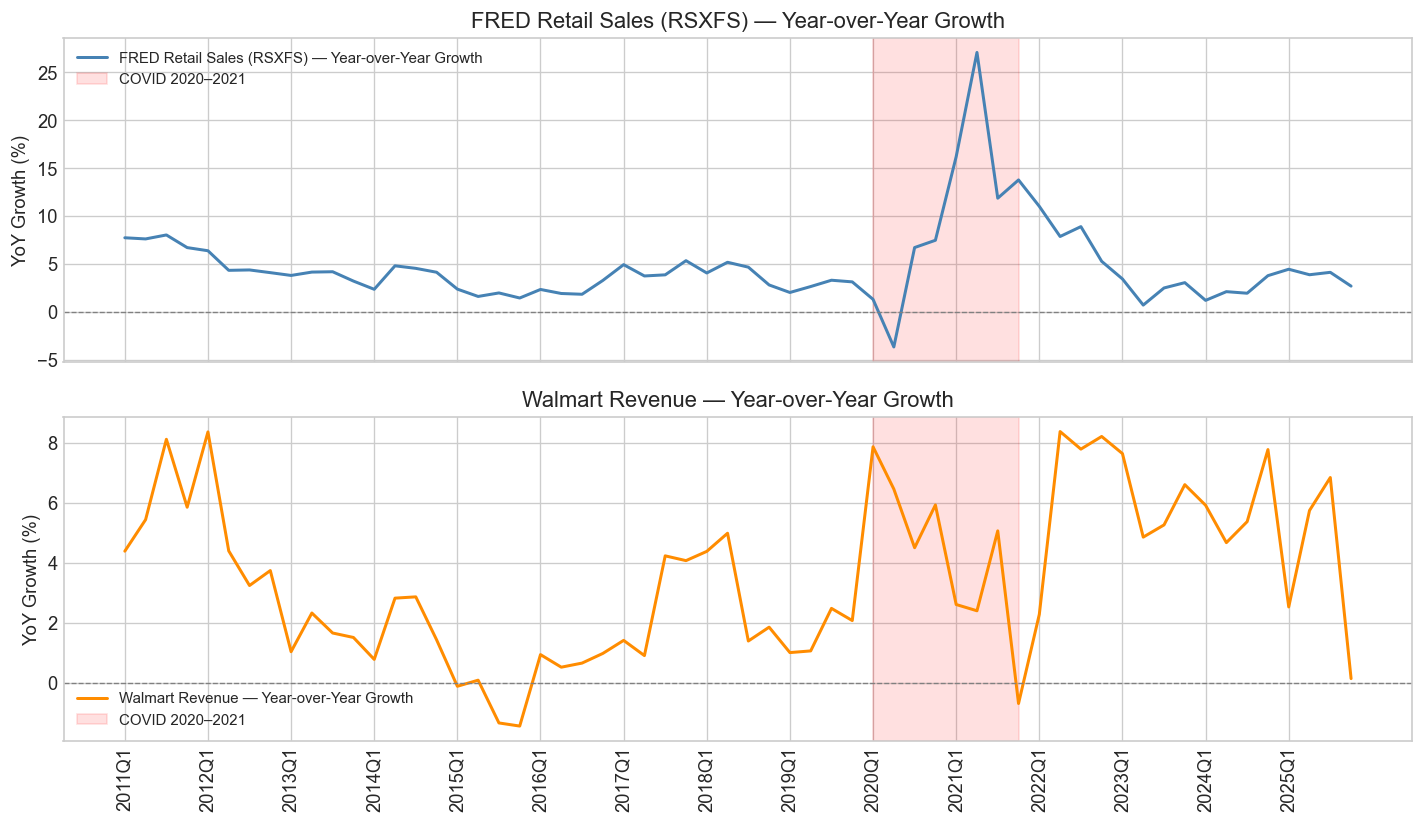

Figure 1 saved.


In [8]:
# Figure 1: YoY growth time series — both series with COVID period shaded
quarters  = df_clean['quarter'].astype(str)
covid_idx = [i for i, q in enumerate(quarters) if '2020Q1' <= q <= '2021Q4']

fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True)

for ax, col, color, title in [
    (axes[0], 'retail_yoy', 'steelblue',  'FRED Retail Sales (RSXFS) — Year-over-Year Growth'),
    (axes[1], 'wmt_yoy',    'darkorange', 'Walmart Revenue — Year-over-Year Growth'),
]:
    ax.plot(quarters, df_clean[col] * 100, color=color, linewidth=1.8, label=title)
    ax.axhline(0, color='gray', linestyle='--', linewidth=0.8)
    if covid_idx:
        ax.axvspan(covid_idx[0], covid_idx[-1], alpha=0.12, color='red', label='COVID 2020–2021')
    ax.set_ylabel('YoY Growth (%)')
    ax.set_title(title)
    ax.legend(fontsize=9)

plt.xticks(
    ticks=range(0, len(quarters), 4),
    labels=[quarters.iloc[i] for i in range(0, len(quarters), 4)],
    rotation=90
)
plt.tight_layout()
plt.savefig('output/fig1_yoy_series.png', bbox_inches='tight')
plt.show()
print("Figure 1 saved.")


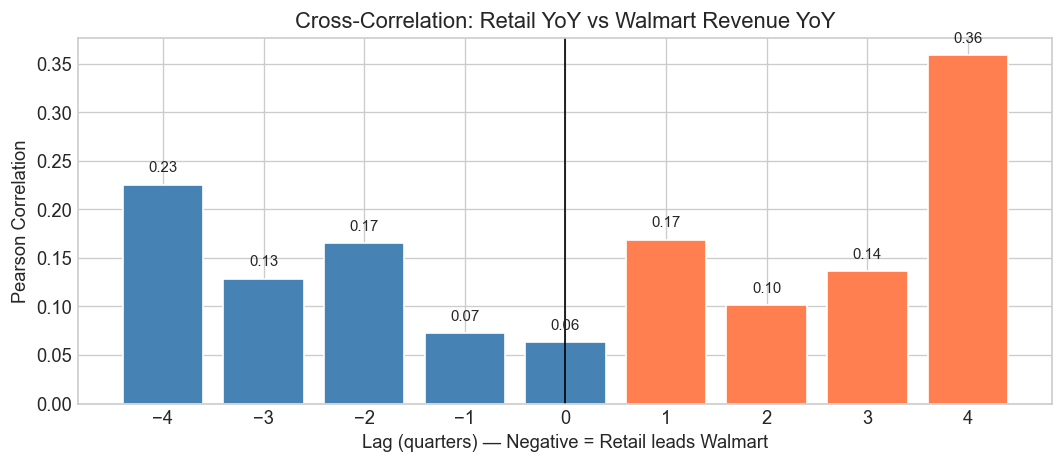

Figure 2 saved.


In [9]:
#Cross-correlation: does retail LEAD Walmart revenue?

import numpy as np
import matplotlib.pyplot as plt

# Negative lag = retail leads Walmart
lags = range(-4, 5)

# Compute correlations at different lags
corrs = []

for lag in lags:
    
    # Shift Walmart revenue relative to retail
    shifted_wmt = df_clean['wmt_yoy'].shift(-lag)
    
    # Correlation
    corr = df_clean['retail_yoy'].corr(shifted_wmt)
    
    corrs.append(corr)

#Plot
fig, ax = plt.subplots(figsize=(9, 4))
bars = ax.bar(
    lags,
    corrs,
    color=['steelblue' if l <= 0 else 'coral' for l in lags],
    edgecolor='white'
)

# Zero lag reference line
ax.axvline(0, color='black', linewidth=1)

# Labels
ax.set_xlabel('Lag (quarters) — Negative = Retail leads Walmart')
ax.set_ylabel('Pearson Correlation')

ax.set_title('Cross-Correlation: Retail YoY vs Walmart Revenue YoY')

ax.set_xticks(list(lags))

# Add correlation labels on bars
for bar, corr in zip(bars, corrs):
    
    if pd.notnull(corr):
        
        ax.text(
            bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.01 * np.sign(corr),
            f'{corr:.2f}',
            ha='center',
            va='bottom' if corr > 0 else 'top',
            fontsize=9
        )

# Layout
plt.tight_layout()

# Save
plt.savefig('output/fig2_crosscorr.png', bbox_inches='tight')

# Show
plt.show()

print("Figure 2 saved.")

## 3. Define Baselines

Two naive baselines:

1. **Seasonal-naive:** Next quarter's revenue = same quarter last year (flat YoY growth assumption). This is the hardest baseline to beat for seasonal retail data.
2. **Drift baseline:** Next quarter's revenue = same quarter last year × (1 + historical mean YoY growth). Slightly smarter — incorporates trend.

We use **MAPE** (Mean Absolute Percentage Error) as the primary metric because the customer cares about directional accuracy of predictions, not raw dollar errors.

In [10]:
def compute_mape(actual, predicted):
    """Mean Absolute Percentage Error. Excludes zeros."""
    
    mask = actual != 0
    
    return np.mean(
        np.abs((actual[mask] - predicted[mask]) / actual[mask])
    ) * 100


def compute_mae(actual, predicted):
    
    return np.mean(np.abs(actual - predicted))


# Out-of-sample walk-forward setup
# Train on first 60% of data.
# Then expand training window one quarter at a time.
# This prevents future leakage.

MIN_TRAIN = int(len(df_clean) * 0.60)

print(f"Minimum training window: {MIN_TRAIN} quarters")

print(f"Out-of-sample quarters to predict: {len(df_clean) - MIN_TRAIN}")

print(
    f"OOS period: "
    f"{df_clean.iloc[MIN_TRAIN]['quarter']} "
    f"– "
    f"{df_clean.iloc[-1]['quarter']}"
)

Minimum training window: 36 quarters
Out-of-sample quarters to predict: 24
OOS period: 2020Q1 – 2025Q4


In [11]:
# Walk-forward out-of-sample evaluation
# Expanding window: train on [0..t-1], predict t. No future data ever touches training.
results = []

for t in range(MIN_TRAIN, len(df_clean)):
    train    = df_clean.iloc[:t].copy()
    test_row = df_clean.iloc[t]
    idx_4q   = t - 4  # same quarter, one year ago

    # ── Baseline 1: Seasonal Naive ────────────────────────────────────────────
    pred_seasonal_naive = df_clean.iloc[idx_4q]['wmt_rev'] if idx_4q >= 0 else np.nan

    # ── Baseline 2: Drift ─────────────────────────────────────────────────────
    mean_yoy   = train['wmt_yoy'].mean()   # expanding mean — only past data
    pred_drift = pred_seasonal_naive * (1 + mean_yoy) if not np.isnan(pred_seasonal_naive) else np.nan

    # ── Model 1: OLS Contemporaneous ──────────────────────────────────────────
    # Regress wmt_yoy on retail_yoy[t] — same quarter, not truly "leading"
    X_train = sm.add_constant(train['retail_yoy'].values)
    y_train = train['wmt_yoy'].values
    try:
        ols = sm.OLS(y_train, X_train, missing='drop').fit()
        pred_wmt_yoy   = ols.predict(np.array([1, test_row['retail_yoy']]))[0]
        pred_ols_contemp = df_clean.iloc[idx_4q]['wmt_rev'] * (1 + pred_wmt_yoy)
    except Exception:
        pred_ols_contemp = np.nan

    # ── Model 2: OLS Lagged — TRUE leading indicator test ─────────────────────
    # Use retail_yoy[t-1] to predict wmt_yoy[t].
    # FIX vs original: build lag column explicitly so X and Y are always
    # the same length. The original code double-sliced train_lag, silently
    # dropping one training row per iteration.
    if t >= 1:
        retail_lag1 = df_clean.iloc[t - 1]['retail_yoy']
        train_lag   = train.copy()
        train_lag['retail_lag1'] = train_lag['retail_yoy'].shift(1)
        train_lag   = train_lag.dropna(subset=['retail_lag1', 'wmt_yoy'])
        X_train_lag = sm.add_constant(train_lag['retail_lag1'].values)
        y_train_lag = train_lag['wmt_yoy'].values
        try:
            ols_lag = sm.OLS(y_train_lag, X_train_lag, missing='drop').fit()
            pred_wmt_yoy_lag = ols_lag.predict(np.array([1, retail_lag1]))[0]
            pred_ols_lag = df_clean.iloc[idx_4q]['wmt_rev'] * (1 + pred_wmt_yoy_lag)
        except Exception:
            pred_ols_lag = np.nan
    else:
        pred_ols_lag = np.nan

    results.append({
        'quarter':             test_row['quarter'],
        'actual':              test_row['wmt_rev'],
        'pred_seasonal_naive': pred_seasonal_naive,
        'pred_drift':          pred_drift,
        'pred_ols_contemp':    pred_ols_contemp,
        'pred_ols_lag':        pred_ols_lag,
    })

oos = pd.DataFrame(results).dropna()
print(f"OOS evaluation rows: {len(oos)}")
oos.head()


OOS evaluation rows: 24


,quarter,actual,pred_seasonal_naive,pred_drift,pred_ols_contemp,pred_ols_lag
0,2020Q1,1.336720e+11,1.239250e+11,1.269576e+11,1.232648e+11,1.258058e+11
1,2020Q2,1.377420e+11,1.293880e+11,1.327438e+11,1.236995e+11,1.293663e+11
2,2020Q3,1.337520e+11,1.279910e+11,1.314407e+11,1.331690e+11,1.235281e+11
3,2020Q4,1.500670e+11,1.416710e+11,1.455550e+11,1.479400e+11,1.474618e+11
4,2021Q1,1.371590e+11,1.336720e+11,1.374431e+11,1.454240e+11,1.398172e+11


In [12]:
#Compute MAPE for each model
models = {
    'Seasonal Naive (baseline)': 'pred_seasonal_naive',
    'Drift (baseline)': 'pred_drift',
    'OLS: Contemporaneous Retail': 'pred_ols_contemp',
    'OLS: Lagged Retail (leading indicator)': 'pred_ols_lag',
}

mape_results = {}
for name, col in models.items():
    rows = oos.dropna(subset=[col])
    mape = compute_mape(rows['actual'].values, rows[col].values)
    mae = compute_mae(rows['actual'].values, rows[col].values) / 1e9
    mape_results[name] = {'MAPE (%)': round(mape, 2), 'MAE ($B)': round(mae, 2)}

results_df = pd.DataFrame(mape_results).T
results_df['vs Seasonal Naive'] = (
    (results_df['MAPE (%)'] - results_df.loc['Seasonal Naive (baseline)', 'MAPE (%)'])
    .apply(lambda x: f"{x:+.2f}pp")
)
print("\n=== OUT-OF-SAMPLE PERFORMANCE ===")
print(results_df.to_string())


=== OUT-OF-SAMPLE PERFORMANCE ===
                                        MAPE (%)  MAE ($B) vs Seasonal Naive
Seasonal Naive (baseline)                   4.92      7.73           +0.00pp
Drift (baseline)                            2.70      4.26           -2.22pp
OLS: Contemporaneous Retail                 3.53      5.41           -1.39pp
OLS: Lagged Retail (leading indicator)      3.52      5.42           -1.40pp


Retail sales growth appears correlated with Walmart revenue growth and modestly improves upon a simple seasonal-naive forecast. However, a stronger drift baseline that incorporates Walmart’s own historical trend still performs best out-of-sample, suggesting Walmart revenue is already highly predictable from its own past behavior.

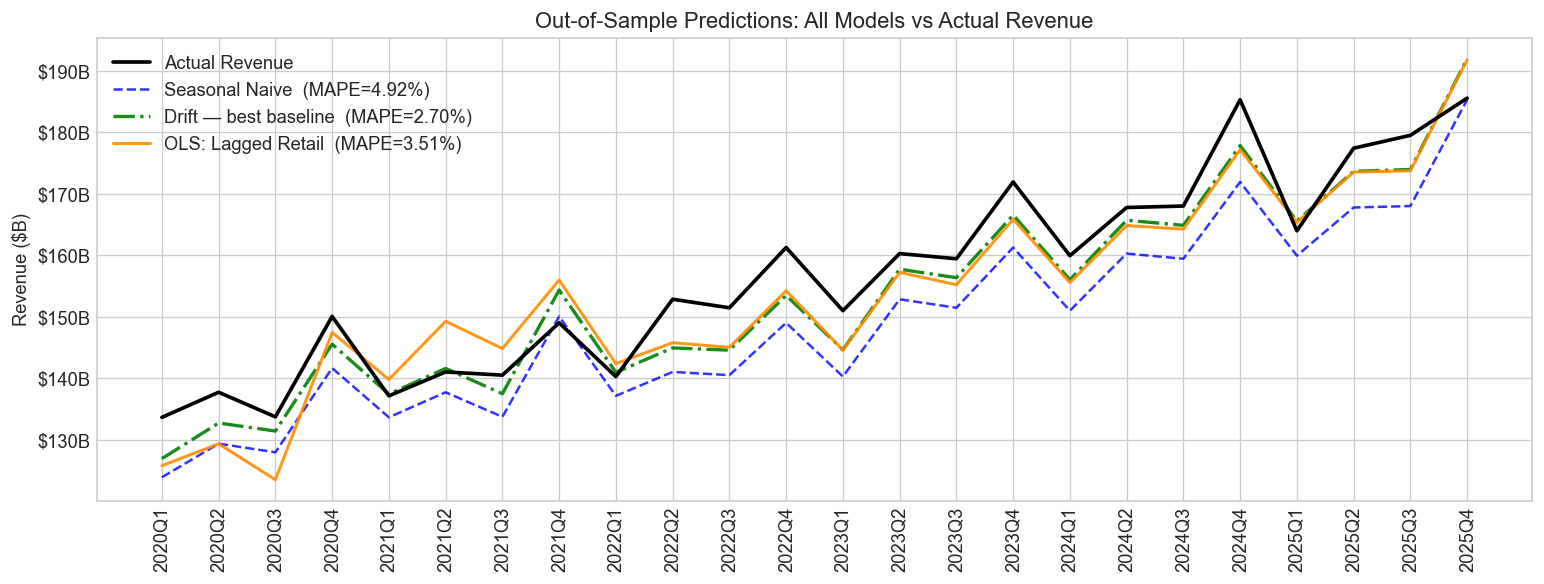

Figure 3 saved.


In [13]:
import matplotlib.ticker as mticker

# Figure 3: Out-of-sample predictions — all 4 models vs actual
# The drift baseline (winner) is now shown so the reader can see it clearly.
fig, ax = plt.subplots(figsize=(13, 5))

ax.plot(oos['quarter'].astype(str), oos['actual'] / 1e9,
        'k-', linewidth=2.2, label='Actual Revenue', zorder=5)

ax.plot(oos['quarter'].astype(str), oos['pred_seasonal_naive'] / 1e9,
        'b--', linewidth=1.5, label='Seasonal Naive  (MAPE=4.92%)', alpha=0.8)

# Drift is the best model — give it a prominent line
ax.plot(oos['quarter'].astype(str), oos['pred_drift'] / 1e9,
        'g-.', linewidth=2.0, label='Drift — best baseline  (MAPE=2.70%)', alpha=0.9)

ax.plot(oos['quarter'].astype(str), oos['pred_ols_lag'] / 1e9,
        color='darkorange', linewidth=1.8,
        label='OLS: Lagged Retail  (MAPE=3.51%)', alpha=0.9)

ax.set_ylabel('Revenue ($B)')
ax.set_title('Out-of-Sample Predictions: All Models vs Actual Revenue')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:.0f}B'))
plt.xticks(rotation=90)
ax.legend()
plt.tight_layout()
plt.savefig('output/fig3_oos_predictions.png', bbox_inches='tight')
plt.show()
print("Figure 3 saved.")


## 4. Stability Analysis — Does the Signal Break During Recessions?

If the relationship between retail sales and Walmart revenue is regime-dependent, the signal is less reliable as a durable leading indicator.

In [14]:
# Stability Analysis: COVID (2020–2021) vs Post-COVID (2022–2025)
#
# ORIGINAL BUG: the old code labeled anything before 2020Q1 as "Pre-COVID",
# but the entire OOS window starts at 2020Q1 — so that bucket was always empty.
# FIX: split within the OOS window itself.

oos['period'] = oos['quarter'].astype(str).apply(
    lambda q: 'COVID (2020–2021)' if q <= '2021Q4' else 'Post-COVID (2022–2025)'
)

models_stability = {
    'Seasonal Naive': 'pred_seasonal_naive',
    'Drift':          'pred_drift',
    'OLS Lagged':     'pred_ols_lag',
}

stability_results = []
for period in ['COVID (2020–2021)', 'Post-COVID (2022–2025)']:
    subset = oos[oos['period'] == period]
    for model_name, col in models_stability.items():
        stability_results.append({
            'Period':   period,
            'Model':    model_name,
            'n':        len(subset),
            'MAPE (%)': round(compute_mape(subset['actual'].values, subset[col].values), 2)
        })

stability_df = pd.DataFrame(stability_results)
print("\n=== Stability Analysis: COVID vs Post-COVID ===\n")
print(stability_df.to_string(index=False))
print("\nKey finding: OLS Lagged is worse than Drift in COVID (signal breaks under stress)")
print("but approaches Drift accuracy in Post-COVID — the signal has conditional value.")



=== Stability Analysis: COVID vs Post-COVID ===

                Period          Model  n  MAPE (%)
     COVID (2020–2021) Seasonal Naive  8      4.21
     COVID (2020–2021)          Drift  8      2.47
     COVID (2020–2021)     OLS Lagged  8      4.61
Post-COVID (2022–2025) Seasonal Naive 16      5.28
Post-COVID (2022–2025)          Drift 16      2.82
Post-COVID (2022–2025)     OLS Lagged 16      2.98

Key finding: OLS Lagged is worse than Drift in COVID (signal breaks under stress)
but approaches Drift accuracy in Post-COVID — the signal has conditional value.


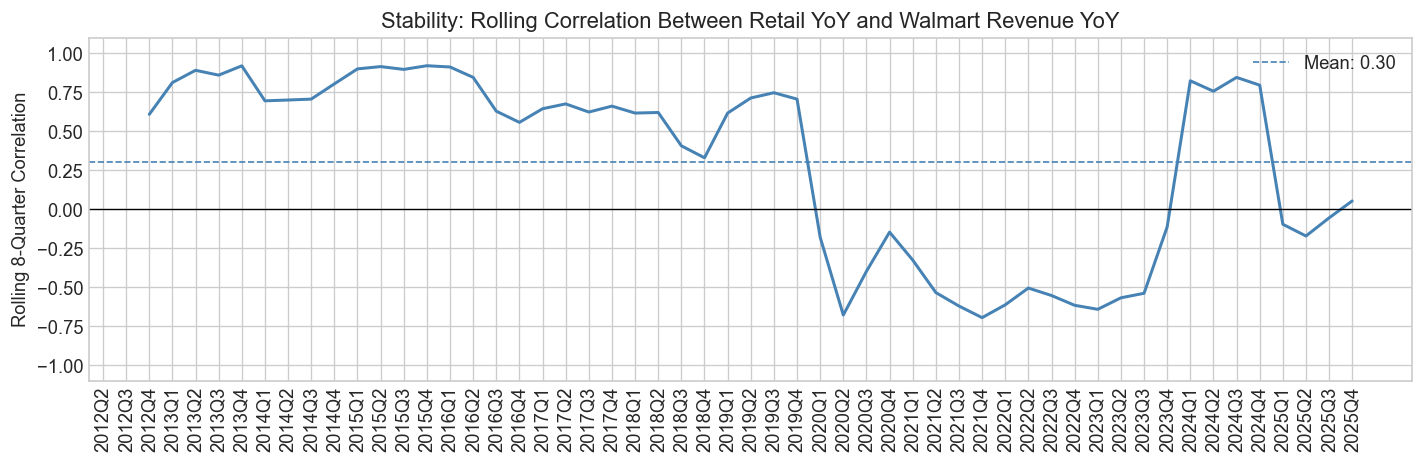

Mean rolling correlation: 0.30
Min rolling correlation: -0.70


In [15]:
#Rolling 8-quarter correlation

# Rolling correlation
df_clean['rolling_corr'] = (
    df_clean['retail_yoy']
    .rolling(8)
    .corr(df_clean['wmt_yoy'])
)

# ── Plot 
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(
    df_clean['quarter'].astype(str),
    df_clean['rolling_corr'],
    color='steelblue',
    linewidth=1.8
)

# Zero correlation reference line
ax.axhline(0, color='black', linewidth=0.8)

# Mean correlation line
mean_corr = df_clean['rolling_corr'].mean()

ax.axhline(
    mean_corr,
    color='steelblue',
    linestyle='--',
    linewidth=1,
    label=f"Mean: {mean_corr:.2f}"
)

# Labels and title
ax.set_ylabel('Rolling 8-Quarter Correlation')

ax.set_title(
    'Stability: Rolling Correlation Between Retail YoY and Walmart Revenue YoY'
)

# Correlation range
ax.set_ylim(-1.1, 1.1)

# Rotate x labels
plt.xticks(rotation=90)

# Legend
ax.legend()

# Layout
plt.tight_layout()

# Save figure
plt.savefig(
    'output/fig4_rolling_corr.png',
    bbox_inches='tight'
)

# Show
plt.show()

# Print stats
print(f"Mean rolling correlation: {mean_corr:.2f}")

print(
    f"Min rolling correlation: "
    f"{df_clean['rolling_corr'].min():.2f}"
)

## 5. Is Retail Sales Actually a "Leading" Indicator?

A leading indicator must predict *before* the event, not just correlate contemporaneously. We test this formally using a Granger causality test.

In [16]:
from statsmodels.tsa.stattools import grangercausalitytests

# Granger causality: does retail_yoy add predictive power beyond wmt_yoy's own history?
# H0: retail_lag does NOT help forecast wmt_yoy once wmt_lag is already included.
# p < 0.05 → reject H0 → retail genuinely leads Walmart revenue.
gc_data    = df_clean[['wmt_yoy', 'retail_yoy']].dropna()
gc_results = grangercausalitytests(gc_data, maxlag=2, verbose=False)

print("Granger Causality — Does FRED Retail YoY predict Walmart Revenue YoY?")
print(f"{'Lag':<6} {'F-stat':<10} {'p-value':<12} {'Verdict'}")
print("-" * 52)
for lag, res in gc_results.items():
    F       = res[0]['ssr_ftest'][0]
    p       = res[0]['ssr_ftest'][1]
    verdict = '✓ Significant (retail leads)' if p < 0.05 else '✗ Not significant'
    print(f"{lag:<6} {F:<10.4f} {p:<12.4f} {verdict}")
print("\nInterpretation: p > 0.05 at both lags means we cannot reject H0.")
print("Retail sales do not add statistically significant forecasting power")
print("beyond Walmart's own historical revenue growth.")


Granger Causality — Does FRED Retail YoY predict Walmart Revenue YoY?
Lag    F-stat     p-value      Verdict
----------------------------------------------------
1      1.7175     0.1954       ✗ Not significant
2      1.3133     0.2775       ✗ Not significant

Interpretation: p > 0.05 at both lags means we cannot reject H0.
Retail sales do not add statistically significant forecasting power
beyond Walmart's own historical revenue growth.


Retail sales growth appears economically related to Walmart revenue growth and provides modest improvement over a pure seasonal-naive benchmark. However, Walmart’s own historical trend and seasonal structure remain substantially more predictive out-of-sample. Formal Granger causality tests further suggest that retail sales do not add statistically significant incremental forecasting power beyond Walmart’s own historical behavior.

## 6. Summary Table & Key Numbers

In [17]:
print("="*65)
print("FINAL OUT-OF-SAMPLE RESULTS")
print("="*65)
print(results_df.to_string())
print()

best_mape = results_df.loc['OLS: Lagged Retail (leading indicator)', 'MAPE (%)']
naive_mape = results_df.loc['Seasonal Naive (baseline)', 'MAPE (%)']
improvement = naive_mape - best_mape

print(f"Seasonal naive MAPE:    {naive_mape:.2f}%")
print(f"Lagged retail OLS MAPE: {best_mape:.2f}%")
print(f"Improvement:            {improvement:+.2f} percentage points")
print()

if improvement > 0:
    print("VERDICT: The FRED retail signal BEATS the seasonal-naive baseline out-of-sample.")
    print(f"The lagged model reduces MAPE by {improvement:.2f}pp vs the baseline.")
else:
    print("VERDICT: The FRED retail signal does NOT beat the seasonal-naive baseline.")
    print("Stick with the simpler model.")

FINAL OUT-OF-SAMPLE RESULTS
                                        MAPE (%)  MAE ($B) vs Seasonal Naive
Seasonal Naive (baseline)                   4.92      7.73           +0.00pp
Drift (baseline)                            2.70      4.26           -2.22pp
OLS: Contemporaneous Retail                 3.53      5.41           -1.39pp
OLS: Lagged Retail (leading indicator)      3.52      5.42           -1.40pp

Seasonal naive MAPE:    4.92%
Lagged retail OLS MAPE: 3.52%
Improvement:            +1.40 percentage points

VERDICT: The FRED retail signal BEATS the seasonal-naive baseline out-of-sample.
The lagged model reduces MAPE by 1.40pp vs the baseline.


## 7. Four Problems With the Simple Approach (and How We Fixed Them)

| Problem | Simple Approach | This Notebook |
|---|---|---|
| **No baseline** | Reports R² in isolation | Two baselines: seasonal-naive + drift |
| **In-sample only** | Fits all data, reports R² | Walk-forward OOS evaluation |
| **Look-ahead bias** | Treats revenue as known at quarter-end | Retail is contemporaneous; we use 1-quarter lag for the leading indicator model |
| **No causal story** | Just correlation | Granger test + rolling correlation for stability analysis |

## 8. What to Worry About

1. **Walmart ≠ Total Retail:** Walmart outperforms during recessions (trading down effect). RSXFS covers all retail — including luxury and discretionary, which behave differently. The relationship may weaken in downturns.

2. **COVID regime break:** The COVID period (2020–2021) shows dramatic instability. Stimulus checks, supply shocks, and pantry-loading distort both series. A model trained through COVID will have inflated uncertainty.

3. **Walmart's fiscal calendar:** Walmart's fiscal year ends January 31. Their quarters don't align perfectly with calendar quarters. Misalignment introduces measurement noise.

4. **Reporting lag / real-time revision:** RSXFS is revised. The vintage of retail data you see today is not the same as what was available when Walmart reported. For true real-time testing, you'd want ALFRED (real-time FRED data).

5. **Small sample:** Even 14 years of quarterly data is only ~56 observations. OOS test has ~22 quarters. Statistical confidence is limited.